<a href="https://colab.research.google.com/github/SaiRitish514/23505A0514/blob/main/finalyearproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
train_dir = "/content/drive/MyDrive/Combined Dataset/train"
test_dir  = "/content/drive/MyDrive/Combined Dataset/test"

In [104]:
import os
train_dir = "/content/drive/MyDrive/Combined Dataset/train"
test_dir  = "/content/drive/MyDrive/Combined Dataset/test"
print("🔹 TRAIN FOLDERS:")
train_classes = os.listdir(train_dir)
print(train_classes)
print("\n🔹 TEST FOLDERS:")
test_classes = os.listdir(test_dir)
print(test_classes)
print("\n✅ Classes match:", set(train_classes) == set(test_classes))

🔹 TRAIN FOLDERS:
['Very Mild Impairment', 'No Impairment', 'Mild Impairment', 'Moderate Impairment']

🔹 TEST FOLDERS:
['Mild Impairment', 'No Impairment', 'Moderate Impairment', 'Very Mild Impairment']

✅ Classes match: True


Found 10258 files belonging to 4 classes.
Using 8207 files for training.
Found 10258 files belonging to 4 classes.
Using 2051 files for validation.
Classes: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


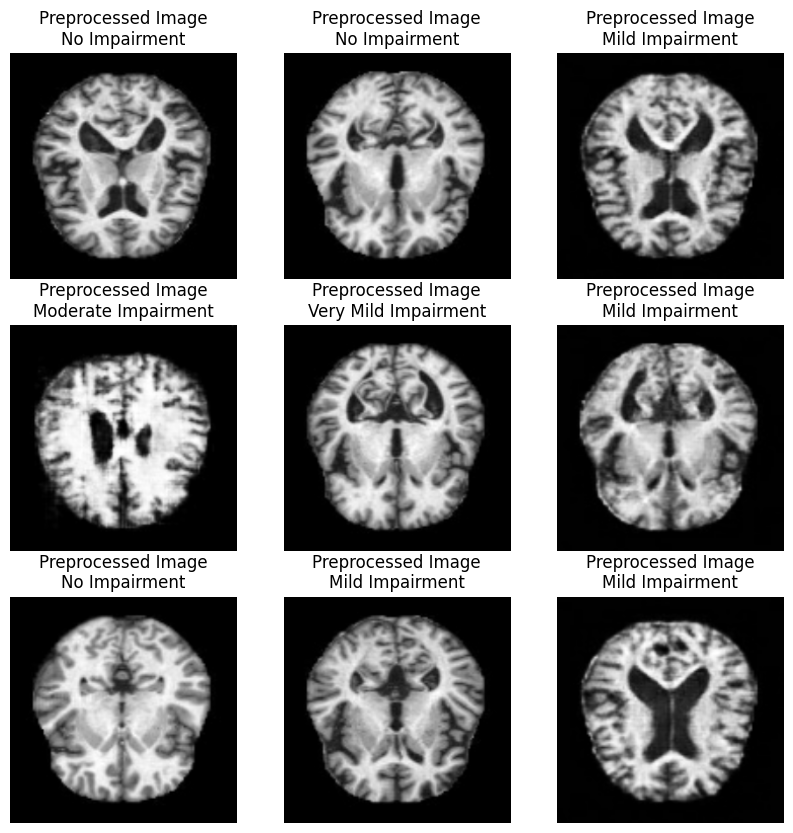

In [103]:
import tensorflow as tf
import matplotlib.pyplot as plt
train_dir = "/content/drive/MyDrive/Combined Dataset/train"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
class_names = train_data.class_names
print("Classes:", class_names)
for images, labels in train_data.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        img = images[i].numpy()
        # normalize for display
        img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img)
        plt.title(f"Preprocessed Image\n{class_names[int(labels[i])]}")
        plt.axis("off")
    plt.show()

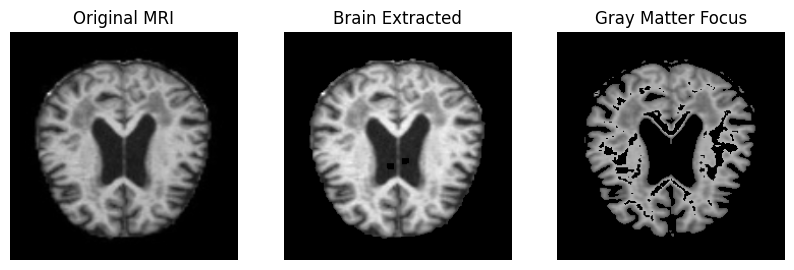

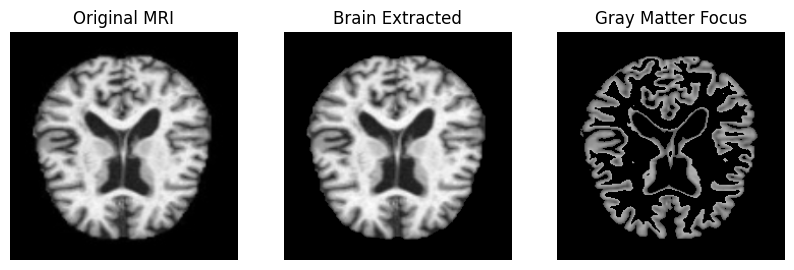

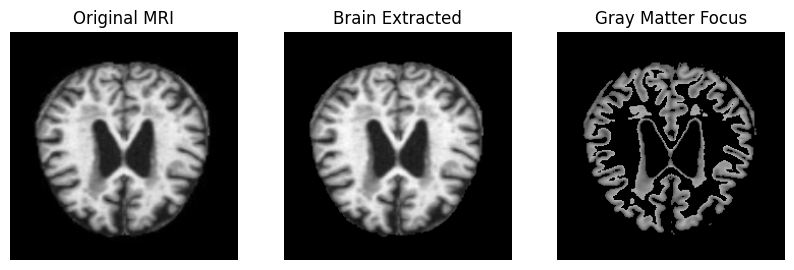

In [102]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
def segment_brain(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found:", image_path)
        return
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    kernel = np.ones((5,5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    brain = cv2.bitwise_and(gray, gray, mask=thresh)
    gm_mask = cv2.inRange(brain, 80, 180)
    gm_highlight = cv2.bitwise_and(img, img, mask=gm_mask)
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original MRI")
    plt.axis("off")
    plt.subplot(1,3,2)
    plt.imshow(brain, cmap='gray')
    plt.title("Brain Extracted")
    plt.axis("off")
    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(gm_highlight, cv2.COLOR_BGR2RGB))
    plt.title("Gray Matter Focus")
    plt.axis("off")
    plt.show()
def run_segmentation(folder_path, num_images=3):
    images = []
    for root, _, files in os.walk(folder_path):
        for f in files:
            if f.endswith(".jpg"):
                images.append(os.path.join(root, f))
    random.shuffle(images)
    for img_path in images[:num_images]:
        segment_brain(img_path)
run_segmentation("/content/drive/MyDrive/Combined Dataset/test", num_images=3)

In [20]:
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

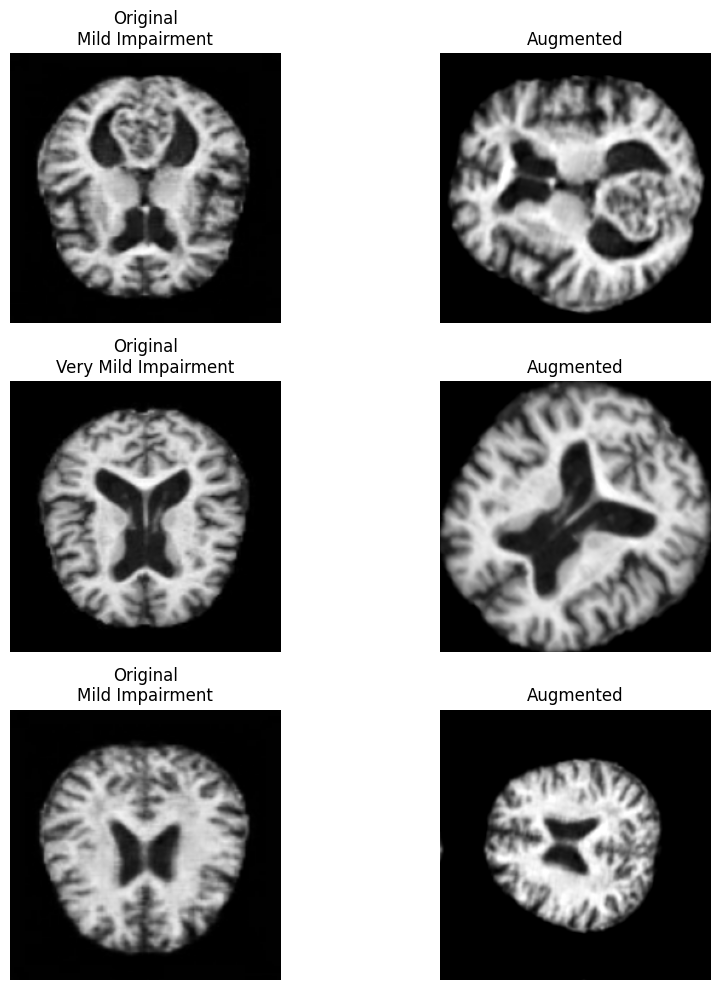

In [101]:
import matplotlib.pyplot as plt
for images, labels in train_data.take(1):
    augmented_images = data_augmentation(images)
    plt.figure(figsize=(10,10))
    for i in range(3):
        plt.subplot(3,2,i*2+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Original\n{class_names[int(labels[i])]}")
        plt.axis("off")
        plt.subplot(3,2,i*2+2)
        img = augmented_images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img)
        plt.title("Augmented")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [100]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
inputs = Input(shape=(224,224,3))
x = data_augmentation(inputs)
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=x)
for layer in base_model.layers[:-50]:
    layer.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(4, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ input_layer_12[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ sequential_2[4][… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 17,476,100 (66.67 MB)

 Non-trainable params: 6,637,184 (25.32 MB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
labels = np.concatenate([y for x, y in train_data], axis=0)
weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(weights))
print(class_weights)

In [40]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 89s 287ms/step - accuracy: 0.6371 - loss: 0.8219 - val_accuracy: 0.6119 - val_loss: 1.1330
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 70s 274ms/step - accuracy: 0.7328 - loss: 0.5847 - val_accuracy: 0.7747 - val_loss: 0.4983
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 83s 277ms/step - accuracy: 0.7690 - loss: 0.5234 - val_accuracy: 0.7977 - val_loss: 0.4343
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 82s 277ms/step - accuracy: 0.7852 - loss: 0.4792 - val_accuracy: 0.8084 - val_loss: 0.4109
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 70s 273ms/step - accuracy: 0.8036 - loss: 0.4457 - val_accuracy: 0.8240 - val_loss: 0.4046
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 70s 273ms/step - accuracy: 0.8145 - loss: 0.4242 - val_accuracy: 0.8206 - val_loss: 0.4303
Epoch 7/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 70s 273ms/step - accuracy: 0.8187 - loss: 0.4073 - val_accuracy: 0.8064 - val_loss: 0.5719
Epoch 8/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 71s 275ms/step - accuracy: 0.8321 - loss: 0

In [51]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [52]:
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[checkpoint]
)

Epoch 1/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9430 - loss: 0.1520
Epoch 1: val_accuracy improved from None to 0.90687, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 124s 390ms/step - accuracy: 0.9488 - loss: 0.1363 - val_accuracy: 0.9069 - val_loss: 0.2908
Epoch 2/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9603 - loss: 0.1061
Epoch 2: val_accuracy improved from 0.90687 to 0.95124, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 97s 375ms/step - accuracy: 0.9567 - loss: 0.1139 - val_accuracy: 0.9512 - val_loss: 0.1512
Epoch 3/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9649 - loss: 0.0939
Epoch 3: val_accuracy did not improve from 0.95124
257/257 ━━━━━━━━━━━━━━━━━━━━ 102s 371ms/step - accuracy: 0.9642 - loss: 0.0956 - val_accuracy: 0.9293 - val_loss: 0.2096
Epoch 4/15
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 3

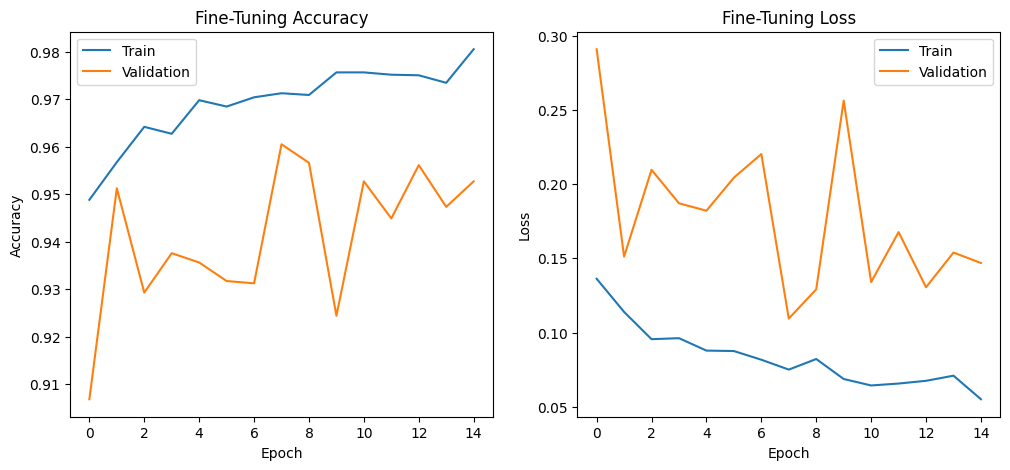

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Validation')
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history2.history['loss'], label='Train')
plt.plot(history2.history['val_loss'], label='Validation')
plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

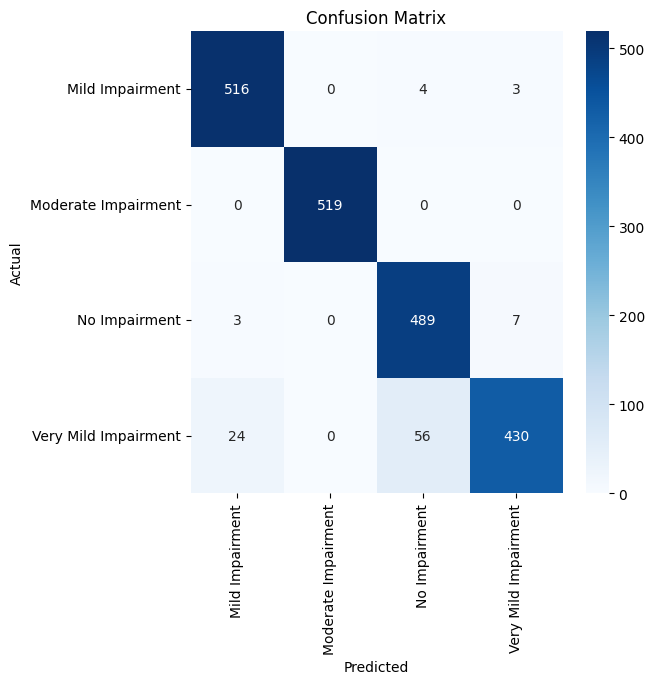


Classification Report:

                      precision    recall  f1-score   support

     Mild Impairment       0.95      0.99      0.97       523
 Moderate Impairment       1.00      1.00      1.00       519
       No Impairment       0.89      0.98      0.93       499
Very Mild Impairment       0.98      0.84      0.91       510

            accuracy                           0.95      2051
           macro avg       0.95      0.95      0.95      2051
        weighted avg       0.96      0.95      0.95      2051



In [55]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Metrics
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

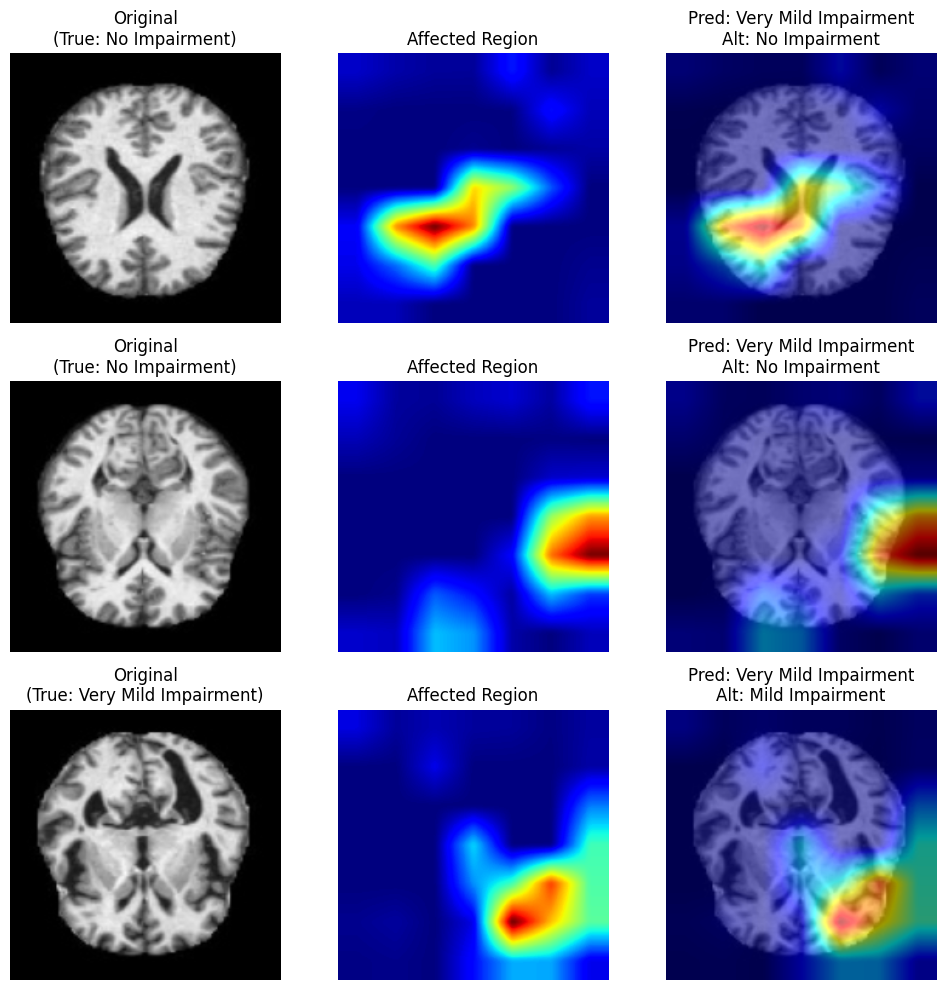

In [99]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
class_names = train_data.class_names
LAST_CONV_LAYER = "conv5_block3_out"
def generate_gradcam(img):
    img = cv2.resize(img, (224,224))
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    arr = tf.keras.applications.resnet50.preprocess_input(img)
    arr = np.expand_dims(arr, axis=0)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(LAST_CONV_LAYER).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(arr)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / np.max(heatmap)
    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.GaussianBlur(heatmap, (7,7), 0)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 0.5, heatmap_color, 0.6, 0)
    probs = predictions[0].numpy()
    top2 = probs.argsort()[-2:][::-1]
    pred_class = class_names[top2[0]]
    alt_class = class_names[top2[1]]
    return rgb, heatmap, overlay, pred_class, alt_class
def show_3_samples(dataset_path):
    images = []
    for root, _, files in os.walk(dataset_path):
        for f in files:
            if f.endswith(".jpg"):
                images.append(os.path.join(root, f))
    random.shuffle(images)
    images = images[:3]
    plt.figure(figsize=(10,10))
    for i, path in enumerate(images):
        true_class = path.split("/")[-2]
        img = cv2.imread(path)
        if img is None:
            continue
        rgb, heatmap, overlay, pred, alt = generate_gradcam(img)
        plt.subplot(3,3,i*3+1)
        plt.imshow(rgb)
        plt.title(f"Original\n(True: {true_class})")
        plt.axis("off")
        plt.subplot(3,3,i*3+2)
        plt.imshow(heatmap, cmap='jet')
        plt.title("Affected Region")
        plt.axis("off")
        plt.subplot(3,3,i*3+3)
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.title(f"Pred: {pred}\nAlt: {alt}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
show_3_samples("/content/drive/MyDrive/Combined Dataset/test")